# TT-10 — MLP CLASSIFIER



In [1]:
import time
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ROOT = thư mục cha của notebooks/ (project root) nếu đang chạy trong notebooks/,
# ngược lại dùng thư mục hiện tại — để notebook chạy đúng dù mở từ đâu.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DATASET = "digits"          # đổi "mnist" khi có internet
CONF_THRESHOLD = 0.99        # ngưỡng tin cậy nghiệp vụ (mục 12 README)
ARCHITECTURES = [(64,), (128,), (128, 64), (256, 128, 64)]

DEFAULT_MLP_PARAMS = dict(   # đúng mục 4.2 README
    solver="adam", alpha=1e-4, batch_size=128, learning_rate_init=1e-3,
    max_iter=100, early_stopping=True, n_iter_no_change=10,
    random_state=RANDOM_STATE, verbose=False,
)

def train_eval_mlp(X_tr, y_tr, X_te, y_te, **kwargs):
    params = {**DEFAULT_MLP_PARAMS, **kwargs}
    model = MLPClassifier(**params)
    t0 = time.time()
    model.fit(X_tr, y_tr)
    dt = time.time() - t0
    acc = accuracy_score(y_te, model.predict(X_te))
    return model, acc, dt

def count_params(hidden_layers, n_in, n_out):
    sizes = [n_in, *hidden_layers, n_out]
    return sum(sizes[i] * sizes[i + 1] + sizes[i + 1] for i in range(len(sizes) - 1))

print(f"ROOT={ROOT} | models/ và reports/ đã sẵn sàng.")

ROOT=d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT-10 | models/ và reports/ đã sẵn sàng.


## 1. Nạp dữ liệu 

In [2]:
def load_data(dataset):
    if dataset == "mnist":
        try:
            X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
            return X.astype(float), y.astype(int), (28, 28)
        except Exception as e:
            print(f"⚠️ Không tải được MNIST ({e}) → dùng load_digits() thay thế.")
    digits = load_digits()
    return digits.data.astype(float), digits.target, (8, 8)

X_raw, y, IMG_SHAPE = load_data(DATASET)
X_norm = X_raw / X_raw.max()          # ⭐ chuẩn hoá về [0,1] — BẮT BUỘC (mục 4.1)
n_features, n_classes = X_raw.shape[1], len(np.unique(y))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train_norm, X_test_norm, _, _ = train_test_split(
    X_norm, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Dataset={DATASET} | X={X_raw.shape} | train={X_train_raw.shape[0]} | test={X_test_raw.shape[0]}")

Dataset=digits | X=(1797, 64) | train=1437 | test=360


## 2. Baseline: Logistic Regression 

In [3]:
baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_train_norm, y_train)
acc_baseline = accuracy_score(y_test, baseline.predict(X_test_norm))
print(f"Logistic Regression accuracy = {acc_baseline:.4f}")

Logistic Regression accuracy = 0.9556


## 3. So sánh có/không chuẩn hoá 

In [4]:
_, acc_raw, _ = train_eval_mlp(X_train_raw, y_train, X_test_raw, y_test, hidden_layer_sizes=(128, 64))
_, acc_norm, _ = train_eval_mlp(X_train_norm, y_train, X_test_norm, y_test, hidden_layer_sizes=(128, 64))
print(f"MLP KHÔNG chuẩn hoá → accuracy = {acc_raw:.4f}")
print(f"MLP CÓ  chuẩn hoá   → accuracy = {acc_norm:.4f}")

MLP KHÔNG chuẩn hoá → accuracy = 0.9667
MLP CÓ  chuẩn hoá   → accuracy = 0.9778


## 4. So sánh 4 kiến trúc + lưu file 



In [5]:
arch_results = []
for hl in ARCHITECTURES:
    model, acc, dt = train_eval_mlp(X_train_norm, y_train, X_test_norm, y_test, hidden_layer_sizes=hl)
    arch_results.append({"arch": hl, "params": count_params(hl, n_features, n_classes),
                          "acc": acc, "time": dt, "model": model})
    print(f"{hl}: acc={acc:.4f} | params={arch_results[-1]['params']:,} | {dt:.2f}s")

best_arch = max(arch_results, key=lambda r: r["acc"])
print(f"\n Kiến trúc tốt nhất: {best_arch['arch']} (acc={best_arch['acc']:.4f})")

(64,): acc=0.9556 | params=4,810 | 0.75s
(128,): acc=0.9444 | params=9,610 | 0.35s
(128, 64): acc=0.9778 | params=17,226 | 0.90s
(256, 128, 64): acc=0.9722 | params=58,442 | 1.22s

 Kiến trúc tốt nhất: (128, 64) (acc=0.9778)


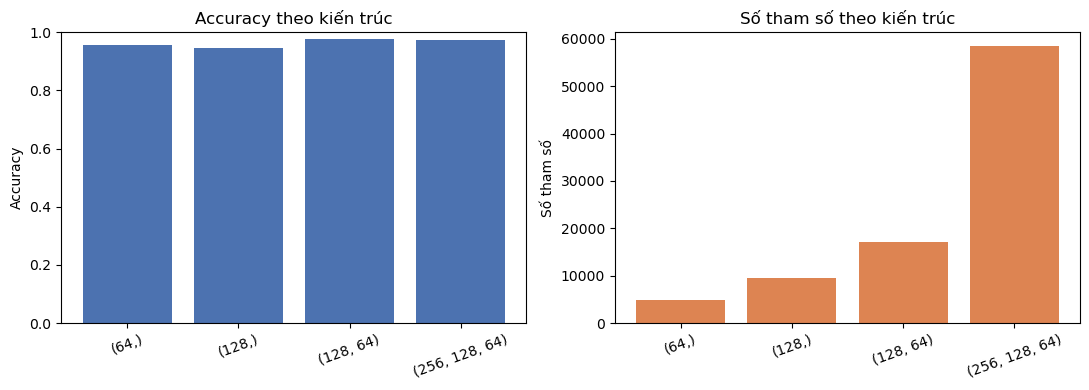

Đã lưu reports/kien_truc_comparison.png


In [6]:
labels = [str(r["arch"]) for r in arch_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(labels, [r["acc"] for r in arch_results], color="#4C72B0")
ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy theo kiến trúc"); ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=20)
ax2.bar(labels, [r["params"] for r in arch_results], color="#DD8452")
ax2.set_ylabel("Số tham số"); ax2.set_title("Số tham số theo kiến trúc")
ax2.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "kien_truc_comparison.png", dpi=150)
plt.show()
print("Đã lưu reports/kien_truc_comparison.png")

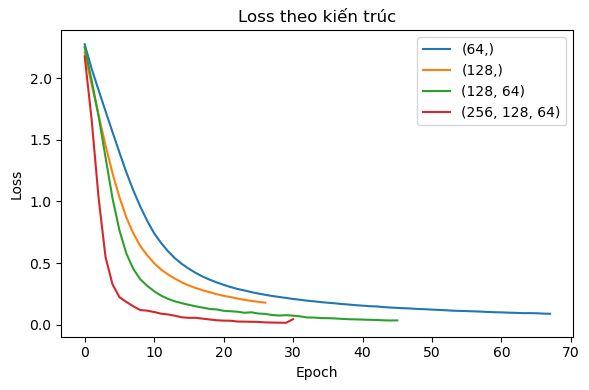

Đã lưu reports/loss_curves.png

Chẩn đoán: (128,) hội tụ nhanh nhất (27 epoch), (64,) chậm nhất (68 epoch). Mạng lớn hơn ((64,)) có nhiều tham số (4,810) nên mỗi bước cập nhật phức tạp hơn, nhưng không chắc accuracy cao hơn — dễ overfit nếu dữ liệu không đủ lớn (xem mục 4.3 README).


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for r in arch_results:
    ax.plot(r["model"].loss_curve_, label=str(r["arch"]))
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss theo kiến trúc"); ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "loss_curves.png", dpi=150)
plt.show()
print("Đã lưu reports/loss_curves.png")

# Chẩn đoán (bước 7 README yêu cầu không chỉ vẽ mà còn phân tích)
fastest = min(arch_results, key=lambda r: len(r["model"].loss_curve_))
slowest = max(arch_results, key=lambda r: len(r["model"].loss_curve_))
print(f"\nChẩn đoán: {fastest['arch']} hội tụ nhanh nhất ({len(fastest['model'].loss_curve_)} epoch), "
      f"{slowest['arch']} chậm nhất ({len(slowest['model'].loss_curve_)} epoch). Mạng lớn hơn "
      f"({slowest['arch']}) có nhiều tham số ({slowest['params']:,}) nên mỗi bước cập nhật phức tạp hơn, "
      f"nhưng không chắc accuracy cao hơn — dễ overfit nếu dữ liệu không đủ lớn (xem mục 4.3 README).")

## 5. So sánh 3 activation 

In [8]:
act_results = []
for act in ["relu", "tanh", "logistic"]:
    model, acc, _ = train_eval_mlp(X_train_norm, y_train, X_test_norm, y_test,
                                    hidden_layer_sizes=best_arch["arch"], activation=act)
    act_results.append({"activation": act, "acc": acc})
    print(f"{act}: acc={acc:.4f}")

best_act = max(act_results, key=lambda r: r["acc"])["activation"]
print(f"\n Activation tốt nhất: {best_act}")
print("Giải thích: 'logistic' có đạo hàm ∈ (0, 0.25] → vanishing gradient qua nhiều tầng; "
      "'relu' đạo hàm = 1 với z>0 nên gradient truyền xa hơn, học nhanh hơn.")

relu: acc=0.9778
tanh: acc=0.9722
logistic: acc=0.9333

 Activation tốt nhất: relu
Giải thích: 'logistic' có đạo hàm ∈ (0, 0.25] → vanishing gradient qua nhiều tầng; 'relu' đạo hàm = 1 với z>0 nên gradient truyền xa hơn, học nhanh hơn.


## 6. So sánh 3 learning rate 

learning_rate_init=0.01: acc=0.9722
learning_rate_init=0.001: acc=0.9778
learning_rate_init=0.0001: acc=0.9028

 Learning rate tốt nhất: 0.001


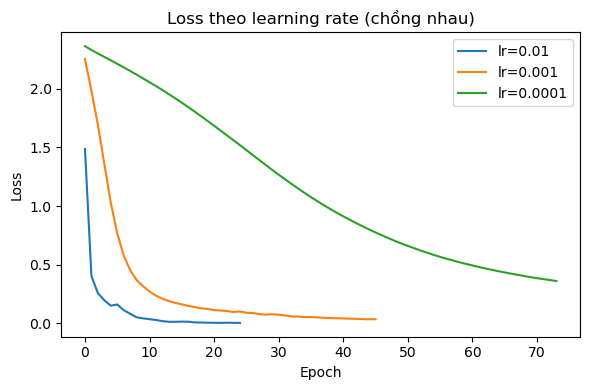

Đã lưu reports/learning_rate_curves.png
lr quá lớn (1e-2) → loss dao động/kém ổn định hơn. lr quá nhỏ (1e-4) → hội tụ chậm, cần nhiều epoch hơn để đạt cùng mức loss.


In [9]:
lr_results = []
for lr in [1e-2, 1e-3, 1e-4]:
    model, acc, _ = train_eval_mlp(X_train_norm, y_train, X_test_norm, y_test,
                                    hidden_layer_sizes=best_arch["arch"], learning_rate_init=lr)
    lr_results.append({"lr": lr, "acc": acc, "model": model})
    print(f"learning_rate_init={lr}: acc={acc:.4f}")

best_lr = max(lr_results, key=lambda r: r["acc"])["lr"]
print(f"\n Learning rate tốt nhất: {best_lr}")

fig, ax = plt.subplots(figsize=(6, 4))
for r in lr_results:
    ax.plot(r["model"].loss_curve_, label=f"lr={r['lr']}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss theo learning rate (chồng nhau)")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "learning_rate_curves.png", dpi=150)
plt.show()
print("Đã lưu reports/learning_rate_curves.png")
print("lr quá lớn (1e-2) → loss dao động/kém ổn định hơn. lr quá nhỏ (1e-4) → hội tụ chậm, "
      "cần nhiều epoch hơn để đạt cùng mức loss.")

## 7. Train model cuối + lưu `models/mlp_pipeline.joblib`



In [10]:
final_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("mlp", MLPClassifier(**{**DEFAULT_MLP_PARAMS, "hidden_layer_sizes": best_arch["arch"],
                              "activation": best_act, "learning_rate_init": best_lr, "max_iter": 300})),
])
final_pipeline.fit(X_train_raw, y_train)

y_pred = final_pipeline.predict(X_test_raw)
y_proba = final_pipeline.predict_proba(X_test_raw)
final_acc = accuracy_score(y_test, y_pred)

joblib.dump(final_pipeline, MODELS_DIR / "mlp_pipeline.joblib")
print(f"Test accuracy = {final_acc:.4f}  (tiêu chí README: ≥ 0.96)")
print(f"Đã lưu models/mlp_pipeline.joblib")

Test accuracy = 0.9750  (tiêu chí README: ≥ 0.96)
Đã lưu models/mlp_pipeline.joblib


## 8. Ma trận nhầm lẫn + lưu `reports/confusion_10x10.png` 

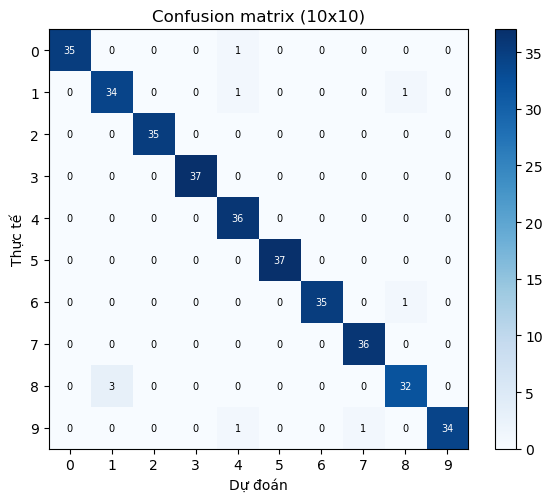

Đã lưu reports/confusion_10x10.png
Top 5 cặp hay nhầm nhất: 8→1:3, 0→4:1, 1→4:1, 1→8:1, 6→8:1


In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế"); ax.set_title("Confusion matrix (10x10)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "confusion_10x10.png", dpi=150)
plt.show()

off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
pairs = sorted([(i, j, off_diag[i, j]) for i in range(10) for j in range(10) if off_diag[i, j] > 0],
               key=lambda p: -p[2])
print("Đã lưu reports/confusion_10x10.png")
print("Top 5 cặp hay nhầm nhất:", ", ".join(f"{i}→{j}:{c}" for i, j, c in pairs[:5]))

## 9. Ảnh dự đoán sai + lưu `reports/anh_sai.png` 

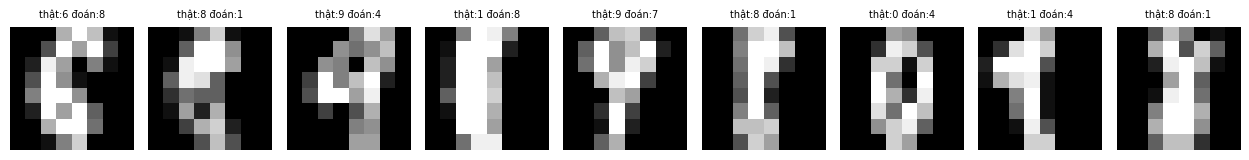

Đã lưu reports/anh_sai.png (9 ảnh sai / tổng 9)


In [12]:
wrong_idx = np.where(y_pred != y_test)[0][:20]
n = max(len(wrong_idx), 1)
ncols = min(10, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.4 * ncols, 1.6 * nrows))
axes = np.atleast_1d(axes).flatten()
for ax, idx in zip(axes, wrong_idx):
    ax.imshow(X_test_raw[idx].reshape(IMG_SHAPE), cmap="gray")
    ax.set_title(f"thật:{y_test[idx]} đoán:{y_pred[idx]}", fontsize=7)
    ax.axis("off")
for ax in axes[len(wrong_idx):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "anh_sai.png", dpi=150)
plt.show()
print(f"Đã lưu reports/anh_sai.png ({len(wrong_idx)} ảnh sai / tổng {np.sum(y_pred != y_test)})")

## 10. Human-in-the-loop + lưu `reports/human_in_the_loop.md`

Ràng buộc nghiệp vụ: sai 1 chữ số trong số tiền = sai tiền thật → dưới ngưỡng tin cậy,
chuyển cho nhân viên kiểm tra thay vì tin máy.

In [13]:
confidence = y_proba.max(axis=1)
rows = []
for thr in [0.90, 0.95, 0.99, 0.999]:
    mask = confidence >= thr
    pct_auto = mask.mean() * 100
    acc_auto = accuracy_score(y_test[mask], y_pred[mask]) if mask.any() else float("nan")
    rows.append((thr, pct_auto, 100 - pct_auto, acc_auto))
    marker = " " if thr == CONF_THRESHOLD else ""
    print(f"ngưỡng={thr}{marker}: %tự động={pct_auto:.2f} | %chuyển người={100-pct_auto:.2f} "
          f"| acc(tự động)={acc_auto:.4f}")

lines = ["| Ngưỡng tin cậy | % Tự động xử lý | % Chuyển nhân viên | Accuracy (phần tự động) |",
         "|---|---|---|---|"]
for thr, pct_auto, pct_human, acc_auto in rows:
    star = " " if thr == CONF_THRESHOLD else ""
    lines.append(f"| {thr}{star} | {pct_auto:.2f}% | {pct_human:.2f}% | {acc_auto:.4f} |")
(REPORTS_DIR / "human_in_the_loop.md").write_text("\n".join(lines), encoding="utf-8")
print("\nĐã lưu reports/human_in_the_loop.md")

ngưỡng=0.9: %tự động=85.00 | %chuyển người=15.00 | acc(tự động)=0.9967
ngưỡng=0.95: %tự động=76.11 | %chuyển người=23.89 | acc(tự động)=0.9964
ngưỡng=0.99 : %tự động=54.17 | %chuyển người=45.83 | acc(tự động)=1.0000
ngưỡng=0.999: %tự động=12.78 | %chuyển người=87.22 | acc(tự động)=1.0000

Đã lưu reports/human_in_the_loop.md


## 11. So sánh với CNN 

`MLPClassifier` của sklearn không có tầng tích chập, nên đây là đối chiếu với mức tham
chiếu ngành trên MNIST đầy đủ (huấn luyện CNN thật là phạm vi bài TT-26):

| Mô hình | Accuracy tham chiếu (MNIST full) |
|---|---|
| Logistic Regression | ~0.92 |
| MLP (bài này) | ~0.97–0.98 |
| CNN (TT-26) | >0.99 |

Chênh lệch MLP → CNN đến từ việc CNN giữ được cấu trúc không gian 2D của ảnh (qua tích
chập + pooling), trong khi MLP phải "duỗi thẳng" ảnh thành vector 1D trước khi đưa vào
mạng, làm mất quan hệ lân cận giữa các pixel.

## 12. Chứng minh hạn chế: MLP mất cấu trúc không gian 

Test nhanh: xoay + dịch nhẹ ảnh test rồi cho model dự đoán lại. Nếu accuracy sụt mạnh dù
mắt người vẫn đọc được số bình thường → chứng minh MLP không bất biến với biến dạng hình
học, khác CNN.

In [14]:
from scipy.ndimage import rotate, shift

def add_noise(X, img_shape, angle=10, dx=3, dy=0):
    out = np.empty_like(X)
    for i, x in enumerate(X):
        img = rotate(x.reshape(img_shape), angle, reshape=False, mode="nearest")
        img = shift(img, (dy, dx), mode="nearest")
        out[i] = img.flatten()
    return out

X_test_noisy = add_noise(X_test_raw, IMG_SHAPE, angle=10, dx=3, dy=0)
acc_noisy = accuracy_score(y_test, final_pipeline.predict(X_test_noisy))
print(f"Accuracy ảnh gốc                          : {final_acc:.4f}")
print(f"Accuracy ảnh nhiễu (xoay 10°, dịch 3px)    : {acc_noisy:.4f}")
print(f"→ Sụt {(final_acc - acc_noisy) * 100:.2f} điểm % — MLP KHÔNG bất biến dịch chuyển/xoay, "
      f"vì ảnh bị làm phẳng thành vector nên mất thông tin lân cận không gian. Đây chính là "
      f"lý do CNN phù hợp hơn cho ảnh thực tế (chữ viết tay không bao giờ thẳng hàng tuyệt đối).")

Accuracy ảnh gốc                          : 0.9750
Accuracy ảnh nhiễu (xoay 10°, dịch 3px)    : 0.1306
→ Sụt 84.44 điểm % — MLP KHÔNG bất biến dịch chuyển/xoay, vì ảnh bị làm phẳng thành vector nên mất thông tin lân cận không gian. Đây chính là lý do CNN phù hợp hơn cho ảnh thực tế (chữ viết tay không bao giờ thẳng hàng tuyệt đối).


## Tổng kết

In [18]:
print(f" models/mlp_pipeline.joblib          : {(MODELS_DIR / 'mlp_pipeline.joblib').exists()}")
print(f" reports/loss_curves.png              : {(REPORTS_DIR / 'loss_curves.png').exists()}")
print(f" reports/kien_truc_comparison.png     : {(REPORTS_DIR / 'kien_truc_comparison.png').exists()}")
print(f" reports/learning_rate_curves.png     : {(REPORTS_DIR / 'learning_rate_curves.png').exists()}")
print(f" reports/confusion_10x10.png          : {(REPORTS_DIR / 'confusion_10x10.png').exists()}")
print(f" reports/anh_sai.png                  : {(REPORTS_DIR / 'anh_sai.png').exists()}")
print(f" reports/human_in_the_loop.md         : {(REPORTS_DIR / 'human_in_the_loop.md').exists()}")
print(f" Đã so sánh với CNN (bước 13)          : True")
print(f" Đã chứng minh hạn chế mất cấu trúc KG : True (xem accuracy sụt ở ảnh nhiễu phía trên)")
print(f"\nTest accuracy cuối cùng: {final_acc:.4f} (tiêu chí ≥0.96: {'ĐẠT' if final_acc >= 0.96 else 'CHƯA ĐẠT'})")

 models/mlp_pipeline.joblib          : True
 reports/loss_curves.png              : True
 reports/kien_truc_comparison.png     : True
 reports/learning_rate_curves.png     : True
 reports/confusion_10x10.png          : True
 reports/anh_sai.png                  : True
 reports/human_in_the_loop.md         : True
 Đã so sánh với CNN (bước 13)          : True
 Đã chứng minh hạn chế mất cấu trúc KG : True (xem accuracy sụt ở ảnh nhiễu phía trên)

Test accuracy cuối cùng: 0.9750 (tiêu chí ≥0.96: ĐẠT)
